# Product Category Clustering

## 1. Import data

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
N_CLUSTERS   = 4
MIN_REVIEWS  = 15   # minimum reviews for a product to be rankable in Part 3

In [2]:
df = pd.read_csv("../data/processed/amazon_reviews_clean.csv")
df = df.dropna(subset=["asins"]).copy()
print(f"Reviews: {len(df):,}   Products: {df['asins'].nunique()}")
df.head()

Reviews: 34,624   Products: 38


,name,brand,categories,reviews.rating,reviews.text,reviews.title,reviews.numHelpful,reviews.doRecommend,sentiment,id,keys,asins
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,This product so far has not disappointed. My c...,Kindle,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,great for beginner or experienced person. Boug...,very fast,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,0.0,True,Positive,AVqkIhwDv8e3D1O-lebb,"841667104676,amazon/53004484,amazon/b01ahb9cn2...",B01AHB9CN2


## 1. Build the product-level table

Collapse 34,624 reviews → 38 products. `categories` and `brand` are taken with
`"first"`, which is only valid because both are constant within an ASIN — the
asserts below prove it rather than assuming it.

In [3]:
products = df.groupby("asins", as_index=False).agg(
    n_reviews=("asins", "size"),
    categories=("categories", "first"),
    brand=("brand", "first"),
    mean_rating=("reviews.rating", "mean"),
)

assert products["asins"].is_unique, "duplicate ASINs"
_const = df.groupby("asins")[["categories", "brand"]].nunique()
_bad = _const[(_const > 1).any(axis=1)]
assert _bad.empty, f"not constant within ASIN:\n{_bad}"

print(f"Product table: {products.shape}")
products.sort_values("n_reviews", ascending=False).head()

Product table: (38, 5)


,asins,n_reviews,categories,brand,mean_rating
26,B018Y229OU,10966,"Fire Tablets,Tablets,Computers & Tablets,All T...",Amazon,4.454222
8,"B00L9EPT8O,B01E6AO69U",6619,"Stereos,Remote Controls,Amazon Echo,Audio Dock...",Amazon,4.671098
17,B00U3FPN4U,5056,"Back To College,College Electronics,College Tv...",Amazon Fire Tv,4.707278
11,B00OQVZDJM,3176,"Walmart for Business,Office Electronics,Tablet...",Amazon,4.772355
32,B01AHB9CN2,2814,"Electronics,iPad & Tablets,All Tablets,Fire Ta...",Amazon,4.586709


## 2. Features — TF-IDF over category strings

Each product's `categories` string (e.g. `"Fire Tablets,Tablets,Computers &
Tablets"`) is vectorised with TF-IDF. `min_df=2` drops tokens unique to a single
product, since those cannot form a group.

In [4]:
tfidf = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    min_df=2,
    token_pattern=r"[a-z][a-z0-9\-&/]+",
)
X = tfidf.fit_transform(products["categories"])
print(f"TF-IDF: {X.shape}")

svd = TruncatedSVD(n_components=12, random_state=RANDOM_STATE)
X_reduced = svd.fit_transform(X)
print(f"SVD: {X_reduced.shape}   explained variance: {svd.explained_variance_ratio_.sum():.1%}")

TF-IDF: (38, 82)
SVD: (38, 12)   explained variance: 88.7%


## 3. Choosing k

**Silhouette is weak evidence on this dataset and we do not rely on it.** With
only 38 points the score drifts upward as k rises (each cluster becomes purer by
construction), so there is no meaningful peak. The curve is flat (~0.32–0.44)
across the whole range, which honestly indicates **no single dominant k**.

`k = 4` is therefore chosen on **interpretability** — it produces four clusters
that map onto recognisable Amazon product families and satisfies the brief's
4–6 meta-category requirement.

  k=2  silhouette=0.315
  k=3  silhouette=0.363
  k=4  silhouette=0.366
  k=5  silhouette=0.419
  k=6  silhouette=0.436
  k=7  silhouette=0.436
  k=8  silhouette=0.440


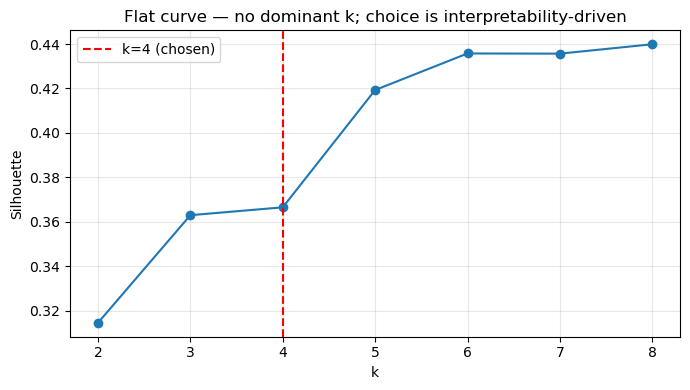

In [5]:
scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
    scores.append(silhouette_score(X_reduced, km.fit_predict(X_reduced)))
    print(f"  k={k}  silhouette={scores[-1]:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(range(2, 9), scores, marker="o")
plt.axvline(N_CLUSTERS, ls="--", c="red", label=f"k={N_CLUSTERS} (chosen)")
plt.xlabel("k"); plt.ylabel("Silhouette"); plt.legend()
plt.title("Flat curve — no dominant k; choice is interpretability-driven")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

In [6]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=50)
products["cluster"] = kmeans.fit_predict(X_reduced)

# Distinctive tokens = mean TF-IDF within cluster minus overall mean
terms = np.array(tfidf.get_feature_names_out())
_X = pd.DataFrame(X.toarray(), columns=terms)
_X["cluster"] = products["cluster"].values
distinct = _X.groupby("cluster").mean() - _X.drop(columns="cluster").mean()

signature = {c: distinct.loc[c].sort_values(ascending=False).head(3).index.tolist()
             for c in range(N_CLUSTERS)}
for c, sig in signature.items():
    print(f"cluster {c}: {sig}")

# Map the top distinctive token -> a readable name (falls back to the raw tokens)
PRETTY = {
    "tablets":     "Fire Tablets",
    "accessories": "Accessories & Cables",
    "home":        "Echo, Fire TV & Smart Home",
    "e-readers":   "Kindle E-Readers",
}
cluster_names = {c: PRETTY.get(sig[0], " / ".join(sig[:2]).title())
                 for c, sig in signature.items()}
products["cluster_name"] = products["cluster"].map(cluster_names)

assert products["cluster_name"].nunique() == N_CLUSTERS, "name collision — check PRETTY"
print("\nNames:", cluster_names)

cluster 0: ['tablets', 'computers', 'frys']
cluster 1: ['accessories', 'cables', 'kindle']
cluster 2: ['home', 'devices', 'categories']
cluster 3: ['e-readers', 'readers', 'ebook']

Names: {0: 'Fire Tablets', 1: 'Accessories & Cables', 2: 'Echo, Fire TV & Smart Home', 3: 'Kindle E-Readers'}


## 4. Cluster profile

`rankable` = products with at least 15 reviews. Part 3 needs **4+ rankable
products per cluster** to produce "top 3 + worst product". The assert enforces
this — if a future change breaks it, the notebook fails here rather than
silently producing a broken article.

In [7]:
products["rankable"] = products["n_reviews"] >= MIN_REVIEWS

summary = (products.groupby("cluster_name")
           .agg(products=("asins", "size"),
                reviews=("n_reviews", "sum"),
                rankable=("rankable", "sum"),
                mean_rating=("mean_rating", "mean"))
           .round(2)
           .sort_values("reviews", ascending=False))
display(summary)

assert (summary["rankable"] >= 4).all(), "a cluster cannot support top-3 + worst"
print("✅ every cluster has >= 4 rankable products")

for c in sorted(products["cluster"].unique()):
    sub = products[products["cluster"] == c].sort_values("n_reviews", ascending=False)
    print(f"\n{'='*74}\n{cluster_names[c]}  —  {len(sub)} products")
    for _, r in sub.head(6).iterrows():
        print(f"  {int(r.n_reviews):>6} rev  {r.mean_rating:.2f}* | {r.categories[:66]}")

,products,reviews,rankable,mean_rating
cluster_name,,,,
Fire Tablets,14,17627,9,4.63
"Echo, Fire TV & Smart Home",8,12345,4,4.50
Kindle E-Readers,6,4092,5,4.70
Accessories & Cables,10,560,4,3.86


✅ every cluster has >= 4 rankable products

Fire Tablets  —  14 products
   10966 rev  4.45* | Fire Tablets,Tablets,Computers & Tablets,All Tablets,Electronics, 
    2814 rev  4.59* | Electronics,iPad & Tablets,All Tablets,Fire Tablets,Tablets,Comput
    1685 rev  4.53* | Tablets,Fire Tablets,Computers & Tablets,All Tablets
    1038 rev  4.50* | Computers/Tablets & Networking,Tablets & eBook Readers,Computers &
     372 rev  4.42* | Electronics Features,Fire Tablets,Computers & Tablets,Tablets,All 
     270 rev  4.56* | Fire Tablets,Tablets,Computers & Tablets,All Tablets,Computers/Tab

Accessories & Cables  —  10 products
     401 rev  4.44* | Amazon Devices & Accessories,Amazon Device Accessories,Power Adapt
      73 rev  4.21* | Chargers & Adapters,Computers & Accessories,Tablet & E-Reader Acce
      16 rev  4.50* | Kindle Store,Categories,eBook Readers & Accessories,Fire TV Access
      15 rev  3.07* | Electronics,eBook Readers & Accessories,Power Adapters,Computers/T
      13 rev 

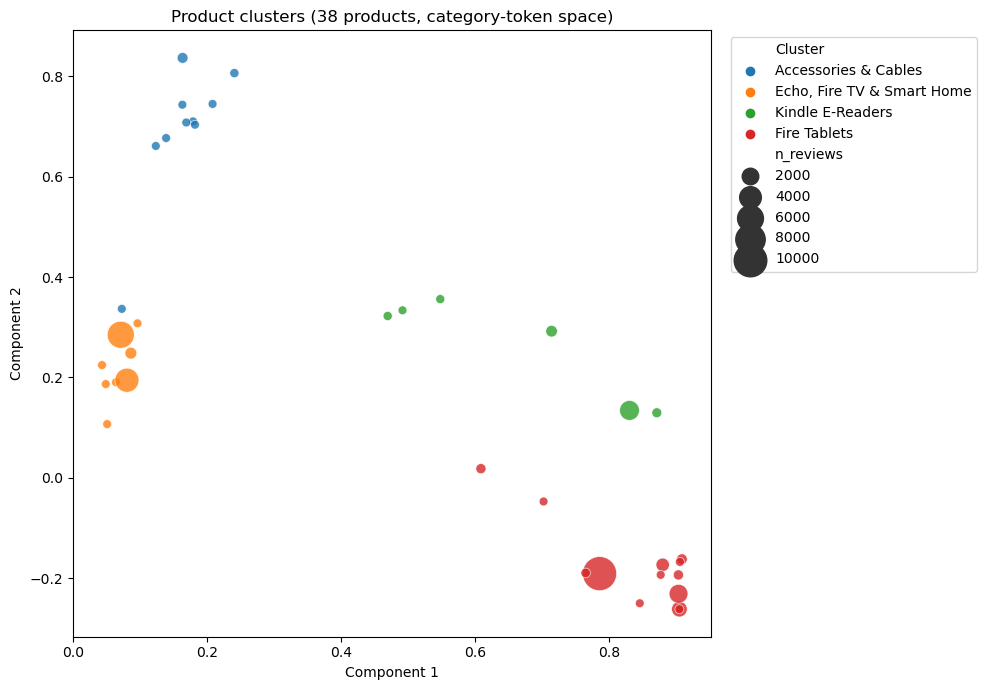

In [8]:
vis = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
vis_df = pd.DataFrame(vis, columns=["Component 1", "Component 2"])
vis_df["Cluster"] = products["cluster_name"].values
vis_df["n_reviews"] = products["n_reviews"].values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=vis_df, x="Component 1", y="Component 2",
                hue="Cluster", size="n_reviews", sizes=(40, 600),
                palette="tab10", alpha=.8)
plt.title("Product clusters (38 products, category-token space)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 5. Persist for Part 3

Cluster labels are joined back onto every review and frozen to disk. Part 3 and
Part 4 read these files — **they must never re-predict**, or a re-run could
reshuffle cluster IDs and invalidate the generated articles.

Saved to `models/kmeans_product/` so the earlier `models/kmeans/` pipeline is
left intact.

In [9]:
reviews = df.merge(products[["asins", "cluster", "cluster_name"]], on="asins", how="left")
assert reviews["cluster"].notna().all(), "reviews lost their cluster in the merge"
assert len(reviews) == len(df), "merge changed the row count"

reviews.to_csv("../data/processed/reviews_with_clusters.csv", index=False)
products.to_csv("../data/processed/product_clusters.csv", index=False)

MODEL_PATH = "../models/kmeans_product"
os.makedirs(MODEL_PATH, exist_ok=True)
for obj, fname in [(tfidf, "tfidf_vectorizer"), (svd, "truncated_svd"),
                   (kmeans, "kmeans_model"), (cluster_names, "cluster_names")]:
    joblib.dump(obj, f"{MODEL_PATH}/{fname}.pkl")

print(f"Saved {len(reviews):,} reviews and {len(products)} products")
print(sorted(os.listdir(MODEL_PATH)))

Saved 34,624 reviews and 38 products
['cluster_names.pkl', 'kmeans_model.pkl', 'tfidf_vectorizer.pkl', 'truncated_svd.pkl']


## 6. Conclusions

Four meta-categories over 38 products:

| Cluster | Products | Reviews | Rankable | Mean rating |
|---|---|---|---|---|
| Fire Tablets | 14 | 17,627 | 9 | 4.63 |
| Echo, Fire TV & Smart Home | 8 | 12,345 | 4 | 4.50 |
| Kindle E-Readers | 6 | 4,092 | 5 | 4.70 |
| Accessories & Cables | 10 | 560 | 4 | 3.86 |

**Notes for Part 3:**
- *Accessories & Cables* is low-volume but has the widest rating spread
  (2.46–4.86) — the strongest material for "worst product" sections.
- Ratings are heavily skewed positive (only ~2% of reviews are negative), so
  complaint mining must draw on the `sentiment` column rather than raw averages.
- `k=4` is an interpretability choice; silhouette is uninformative at n=38.